# EDA - Maintenance Prédictive Industrielle

**Objectif :** comprendre le dataset `predictive_maintenance_v3.csv` avant toute modélisation.

**Variable cible retenue :** `failure_within_24h` (classification binaire, prédire si une panne survient dans les 24h)

## 1. Chargement des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

os.makedirs('../outputs/figures', exist_ok=True)

df = pd.read_csv('C:\Users\suzan\OneDrive\Bureau\PROJET DS M1\data\raw\predictive_maintenance.csv', sep=';')
print(f"Shape : {df.shape}")
df.head()

Shape : (24042, 15)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


## 2. Vue d'ensemble : types, valeurs manquantes, doublons

In [2]:
df.dtypes

timestamp                      str
machine_id                   int64
machine_type                   str
vibration_rms              float64
temperature_motor          float64
current_phase_avg          float64
pressure_level             float64
rpm                        float64
operating_mode                 str
hours_since_maintenance    float64
ambient_temp               float64
rul_hours                  float64
failure_within_24h           int64
failure_type                   str
estimated_repair_cost        int64
dtype: object

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'manquantes': missing, 'pourcentage': missing_pct})

,manquantes,pourcentage
timestamp,0,0.00
machine_id,0,0.00
machine_type,0,0.00
vibration_rms,1000,4.16
temperature_motor,834,3.47
current_phase_avg,731,3.04
pressure_level,924,3.84
rpm,533,2.22
operating_mode,0,0.00
hours_since_maintenance,0,0.00


In [4]:
print(f"Lignes dupliquées : {df.duplicated().sum()}")
print(f"\nMachines uniques : {df['machine_id'].nunique()}")
print(df['machine_type'].value_counts())

Lignes dupliquées : 0

Machines uniques : 20
machine_type
Pump           6114
Robotic Arm    6003
Compressor     5988
CNC            5937
Name: count, dtype: int64


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
machine_id,24042.0,10.505033,5.746455,1.00,6.00,10.00,15.0000,20.00
vibration_rms,23042.0,1.623667,1.081061,0.35,0.82,1.27,2.2700,10.00
temperature_motor,23208.0,51.404295,12.519279,28.00,42.61,50.06,59.9625,95.00
current_phase_avg,23311.0,8.823829,5.366391,2.20,4.63,6.43,13.1200,35.00
pressure_level,23118.0,59.012233,38.723271,10.10,22.70,46.30,94.7000,206.50
rpm,23509.0,1144.849317,912.670971,124.10,489.40,856.00,1676.0000,4098.80
hours_since_maintenance,24042.0,172.630624,150.722469,0.00,42.87,121.61,295.5750,575.63
ambient_temp,24042.0,12.996398,2.883994,8.00,10.50,13.00,15.5000,18.00
rul_hours,24042.0,27.812510,26.393801,0.50,0.50,22.57,46.4100,98.34
failure_within_24h,24042.0,0.148074,0.355181,0.00,0.00,0.00,0.0000,1.00


**Interprétation :**
- Le dataset présente des valeurs manquantes uniquement sur les 5 variables vibration_rms, temperature_motor, current_phase_avg, pressure_level, rpm, avec un taux compris 
  entre 2.22% (rpm) et 4.16% (vibration_rms). Aucune valeur manquante sur les variables catégorielles, 
  temporelles ou sur la cible. Ce niveau de manquant (2-4%) est modéré et ne nécessite pas de suppression 
  de lignes : une imputation simple (par exemple par la médiane, peu sensible aux valeurs extrêmes déjà 
  repérées sur certains capteurs) sera privilégiée à l'étape de preprocessing.
- Aucun doublon n'a été détecté sur l'ensemble des 24 042 lignes.
- Les 20 machines sont réparties de façon équilibrée entre les 4 types : Pump (6114), Robotic Arm (6003), 
  Compressor (5988), CNC (5937), environ 25% chacun. Aucun déséquilibre structurel entre types de 
  machines n'est à signaler à ce stade.


## 3. Distribution de la variable cible `failure_within_24h`

On va vérifier le déséquilibre des classes avant toute modélisation.

In [6]:
target_dist = df['failure_within_24h'].value_counts(normalize=True)
print(target_dist)

ratio = target_dist[0] / target_dist[1]
print(f"\nRatio de déséquilibre (classe majoritaire / minoritaire) : {ratio:.2f}")

failure_within_24h
0    0.851926
1    0.148074
Name: proportion, dtype: float64

Ratio de déséquilibre (classe majoritaire / minoritaire) : 5.75


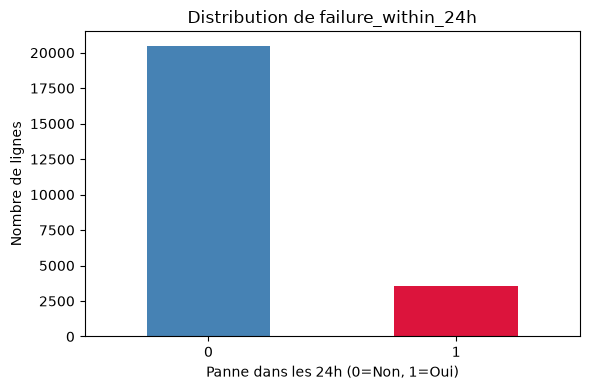

In [7]:
plt.figure(figsize=(6, 4))
df['failure_within_24h'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'])
plt.title('Distribution de failure_within_24h')
plt.xlabel('Panne dans les 24h (0=Non, 1=Oui)')
plt.ylabel('Nombre de lignes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/01_distribution_target.png', dpi=120)
plt.show()

**Interprétation :**
- Le ratio de déséquilibre calculé est d'environ 5.76 : pour une ligne en panne (failure_within_24h=1), 
  on compte environ 5.76 lignes sans panne (failure_within_24h=0). En proportions, cela représente 
  14.8% de cas positifs contre 85.2% de cas négatifs. Il s'agit d'un déséquilibre modéré.
- Conséquence pour la modélisation : un modèle qui prédirait toujours "pas de panne" aurait déjà 
  85.2% d'accuracy, alors qu'il serait inutile en pratique puisqu'il ne détecterait jamais une seule 
  panne. L'accuracy seule ne suffit donc pas pour juger nos modèles. On utilisera plutôt le Recall, 
  le F1-score et le ROC-AUC/PR-AUC, avec un split stratifié, et on testera des techniques de 
  rééquilibrage (SMOTE, over/under-sampling) ainsi qu'un ajustement du seuil de décision.


## 4. Distributions des variables capteurs

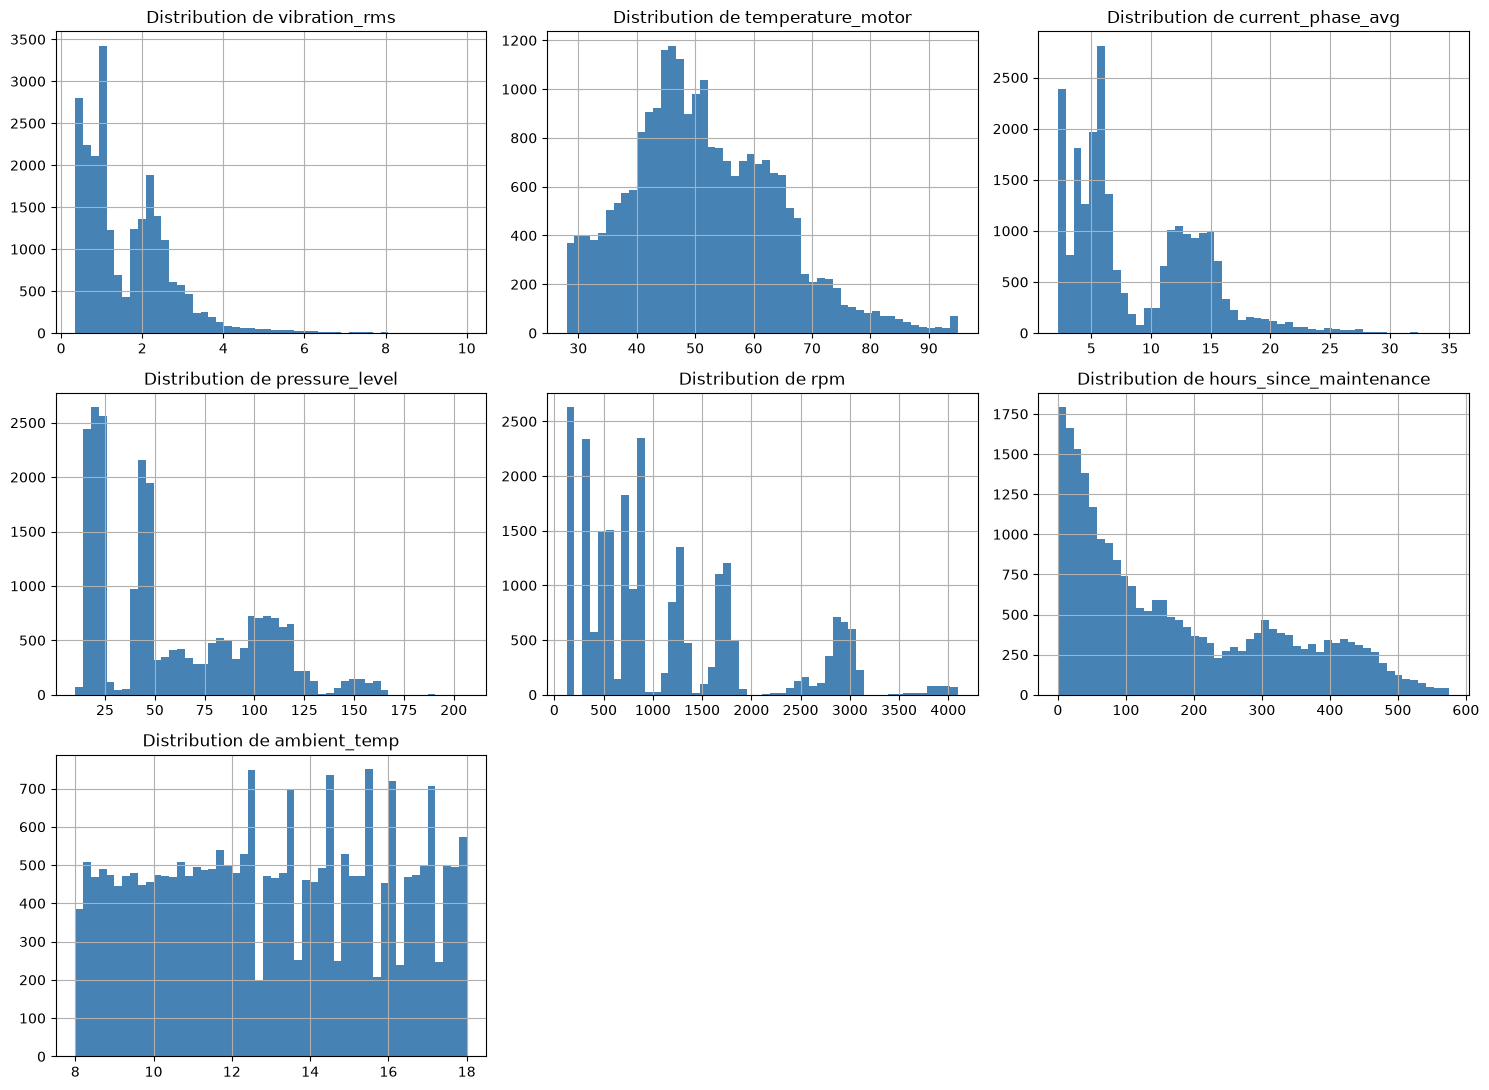

In [9]:
sensor_cols = ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 
               'rpm', 'hours_since_maintenance', 'ambient_temp']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), sensor_cols):
    df[col].hist(bins=50, ax=ax, color='steelblue')
    ax.set_title(f'Distribution de {col}')

# Cacher les cases vides (3x3 = 9 cases, on n'a que 7 variables)
for ax in axes.flatten()[len(sensor_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/02_distributions_capteurs.png', dpi=120)
plt.show()

**Interprétation :**
- `temperature_motor` suit une courbe classique en cloche, centrée vers 50°C.
- `vibration_rms`, `current_phase_avg`, `pressure_level` et `rpm` ont plusieurs pics au lieu d'une 
  seule bosse. C'est probablement lié aux 4 types de machines, qui ont chacun des plages de 
  fonctionnement différentes.
- `hours_since_maintenance` décroît progressivement depuis 0, avec une bosse secondaire vers 300h : 
  beaucoup de mesures sont prises peu de temps après une maintenance, ce qui est logique.
- `ambient_temp` a une forme en dents de scie irrégulière, sans vraie tendance : probablement lié 
  à des variations jour/nuit ou saisonnières plutôt qu'à un phénomène lié aux pannes.
- Quelques valeurs très élevées et isolées apparaissent en fin de distribution (ex. vibration_rms 
  au-delà de 6), à garder en tête comme outliers possibles, mais peut-être aussi des signaux 
  avant une panne.

## 5. Corrélations entre variables numériques

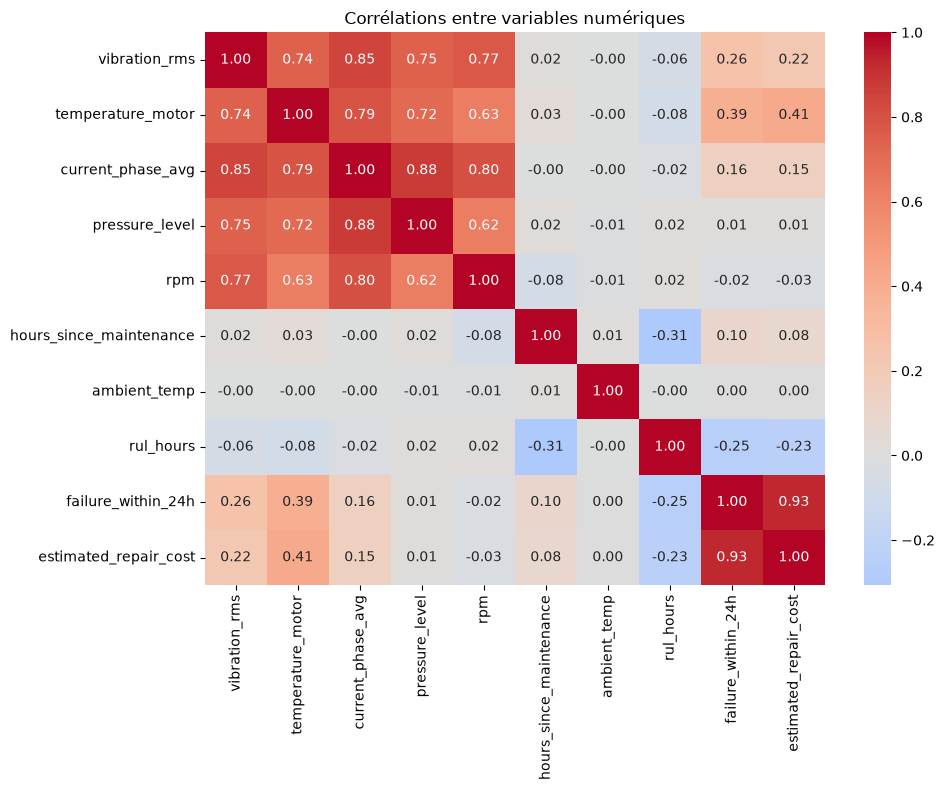

In [10]:
numeric_cols = df.select_dtypes(include='number').columns.drop('machine_id')

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Corrélations entre variables numériques')
plt.tight_layout()
plt.savefig('../outputs/figures/03_heatmap_correlations.png', dpi=120)
plt.show()

**Interprétation :**
- Les variables les plus corrélées avec `failure_within_24h` sont `temperature_motor` (0.39), 
  `vibration_rms` (0.26), `rul_hours` (-0.25, négative car moins de durée de vie restante = panne 
  plus probable) et `hours_since_maintenance` (0.10). `current_phase_avg`, `pressure_level`, `rpm` 
  et `ambient_temp` ne sont quasiment pas corrélés avec la cible (entre -0.02 et 0.16).
- Point important : `estimated_repair_cost` est corrélé à 0.93 avec `failure_within_24h`. C'est trop 
  élevé pour être un signal prédictif normal, ça indique que le coût de réparation est calculé après 
  la panne (donc une conséquence, pas une cause). Cette variable sera exclue des variables explicatives 
  pour éviter une fuite de données (data leakage).
- Les capteurs `vibration_rms`, `current_phase_avg`, `pressure_level` et `rpm` sont fortement corrélés 
  entre eux (0.62 à 0.88), probablement parce qu'ils dépendent tous du type de machine. Cette redondance 
  est à garder en tête, surtout pour les modèles linéaires.


## 6. Capteurs selon panne / pas panne

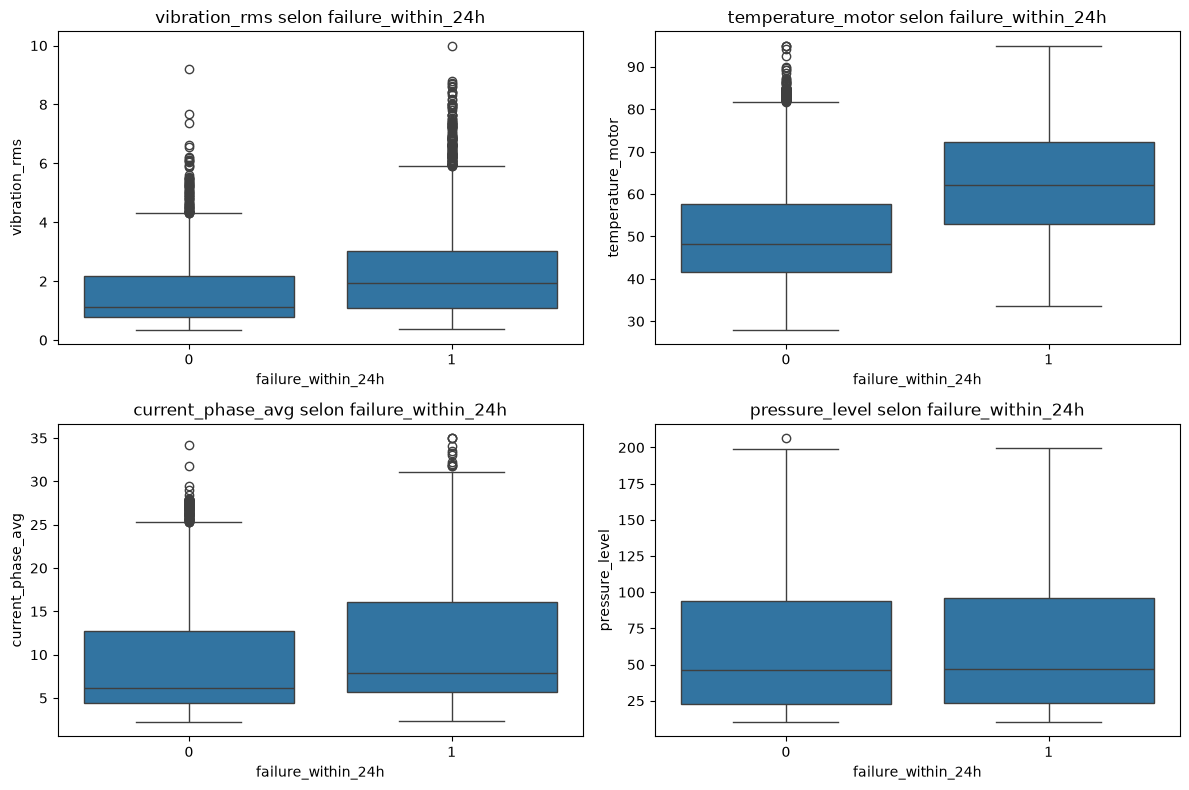

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), sensor_cols):
    sns.boxplot(data=df, x='failure_within_24h', y=col, ax=ax)
    ax.set_title(f'{col} selon failure_within_24h')
plt.tight_layout()
plt.savefig('../outputs/figures/04_boxplots_capteurs_vs_cible.png', dpi=120)
plt.show()

**Interprétation :**
- `temperature_motor` est le capteur qui se distingue le plus nettement : médiane à 48°C sans panne 
  contre 62°C avec panne, avec des boîtes qui ne se chevauchent presque pas. C'est le signal le plus 
  visible d'une panne à venir.
- `vibration_rms` montre aussi une différence claire : médiane plus haute et boîte plus large en cas 
  de panne.
- `current_phase_avg` montre une légère tendance similaire, mais moins marquée.
- `pressure_level` ne montre presque aucune différence entre les deux groupes, ce capteur seul ne 
  semble pas être un bon indicateur de panne.
- Intuition métier : une température motor au-delà de 55-60°C combinée à une vibration plus élevée 
  semble être le profil le plus associé à un risque de panne dans les 24h.

## 7. Synthèse des insights EDA

- **Déséquilibre modéré de la cible.** Seulement 14.8% des lignes correspondent à une 
  panne dans les 24h (ratio ~5.76). L'accuracy seule serait trompeuse pour évaluer les modèles : il 
  faudra utiliser Recall, F1-score, ROC-AUC/PR-AUC, un split stratifié, et tester des techniques de 
  rééquilibrage (SMOTE, over/under-sampling) ainsi qu'un ajustement du seuil de décision.

- **La température motor est le signal le plus fort de panne.** C'est la variable la 
  plus corrélée avec la cible (0.39) et celle qui se distingue le plus nettement dans les boxplots 
  (médiane 48°C sans panne vs 62°C avec panne). La vibration (`vibration_rms`) est le deuxième signal 
  le plus utile. À l'inverse, `pressure_level` et `ambient_temp` n'apportent presque aucune information 
  sur le risque de panne.

- **Une fuite de données à éviter.** `estimated_repair_cost` est corrélé à 0.93 avec la 
  cible, car ce coût est calculé après la panne, pas avant. Cette variable doit être exclue du 
  modèle pour ne pas fausser artificiellement les résultats.

- **Qualité des données globalement bonne.** Pas de doublons, valeurs manquantes limitées 
  (2 à 4%) sur les 5 capteurs numériques, machines bien réparties entre les 4 types. Une imputation 
  simple (médiane) suffira en preprocessing.

- **Redondance entre capteurs liée au type de machine.** `vibration_rms`, `current_phase_avg`, 
  `pressure_level` et `rpm` sont fortement corrélés entre eux (0.62 à 0.88), probablement parce que 
  chaque type de machine (Pump, Robotic Arm, Compressor, CNC) a ses propres plages de fonctionnement 
  normales. Cette redondance sera à surveiller pour les modèles linéaires.
